# Series temporales. Predicción de ventas

El objetivo de este notebook es analizar la evolución de las ventas y preparar un modelo `ARIMA` para predecir ventas futuras.

La idea es usar la serie temporal para ayudar a estimar el ritmo de ventas antes de abrir un nuevo almacén.


## 1. Imports

En esta sección importo las librerías necesarias para trabajar con datos, gráficos, análisis de series temporales y modelos `ARIMA`.


In [149]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

from sklearn.metrics import mean_absolute_error, mean_squared_error

import joblib

import warnings

warnings.filterwarnings(
    "ignore",
    message="'force_all_finite' was renamed to 'ensure_all_finite'",
    category=FutureWarning,
)
from typing import Any


SEPARATOR = 120 * "-"

## 2. Carga del dataset

Cargo el archivo `sales.csv` desde la carpeta `data/raw/` y reviso las primeras filas para comprobar que se ha leído correctamente.


In [150]:
df = pd.read_csv("../data/raw/sales.csv")

display(df.head())

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633


## 3. Primera exploración del dataset

In [151]:
print(f"Shape:\n{df.shape}")
print(SEPARATOR)

print("Info:")
display(df.info())
print(SEPARATOR)

print("Nulos:")
display(df.isnull().sum())
print(SEPARATOR)

print("Métricas:")
display(df.describe())

Shape:
(366, 2)
------------------------------------------------------------------------------------------------------------------------
Info:
<class 'pandas.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    366 non-null    str    
 1   sales   366 non-null    float64
dtypes: float64(1), str(1)
memory usage: 5.8 KB


None

------------------------------------------------------------------------------------------------------------------------
Nulos:


date     0
sales    0
dtype: int64

------------------------------------------------------------------------------------------------------------------------
Métricas:


,sales
count,366.000000
mean,524.963968
std,275.089698
min,53.803211
25%,290.186822
50%,520.699468
75%,763.289263
max,1000.482785


## 4. Construcción de la serie temporal

In [152]:
df["date"] = pd.to_datetime(df["date"]).dt.normalize()

df = df.set_index("date")
df = df.sort_index()
df = df.asfreq("D")

display(df.head())

,sales
date,
2022-09-03,55.292157
2022-09-04,53.803211
2022-09-05,58.141693
2022-09-06,64.530899
2022-09-07,66.013633


Fijo la frecuencia diaria con `asfreq("D")` porque la serie tiene registros diarios.

Esto evita que `statsmodels` tenga que inferir la frecuencia al entrenar el modelo `ARIMA`.

## 5. Visualización inicial de la serie

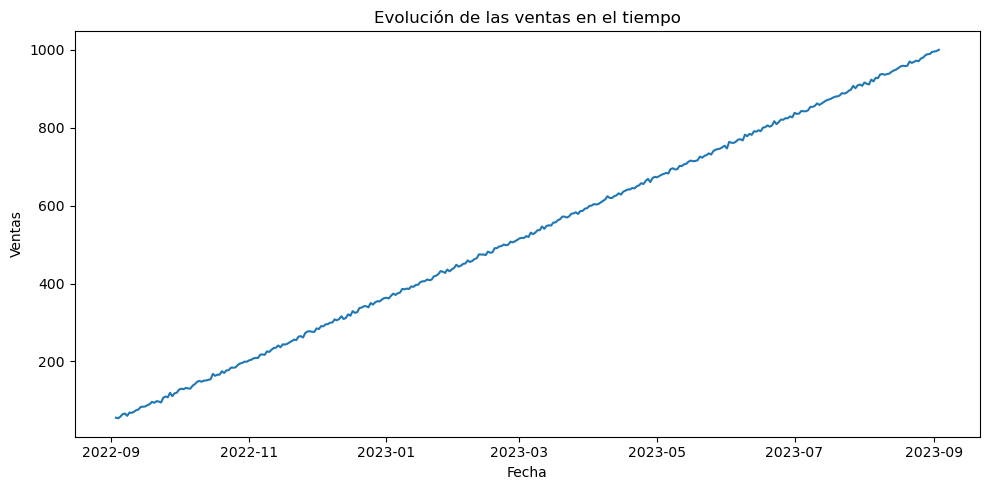

In [153]:
fig, axis = plt.subplots(figsize=(10, 5))

sns.lineplot(data=df, x=df.index, y="sales", ax=axis)

plt.title("Evolución de las ventas en el tiempo")
plt.xlabel("Fecha")
plt.ylabel("Ventas")

plt.tight_layout()
plt.show()

## 6. Análisis de la serie temporal

#### `Tendencia:`
Tendencia ascendente.

#### `Estacionalidad:`
No se aprecia claramente un patrón estacional fuerte, será necesario revisar la descomposición de la serie y la autocorrelación.

#### `Variabilidad:`
La serie tiene algo de variabilidad entre puntos cercanos, pero no parece extremadamente irregular.

#### `Outliers:`
No se observan valores extremos muy evidentes.

#### `Puntos de inflexión:`
No veo un punto de inflexión fuerte en el gráfico. Se mantiene una trayectoria ascendente bastante estable durante casi todo el periodo observado.

## 7. Descomposición de la serie

Como los datos son diarios, uso `period=30` para observar un posible patrón mensual aproximado. Lo voy a comparar con `period=7` para ver si hay más de un comportamiento que se repite.

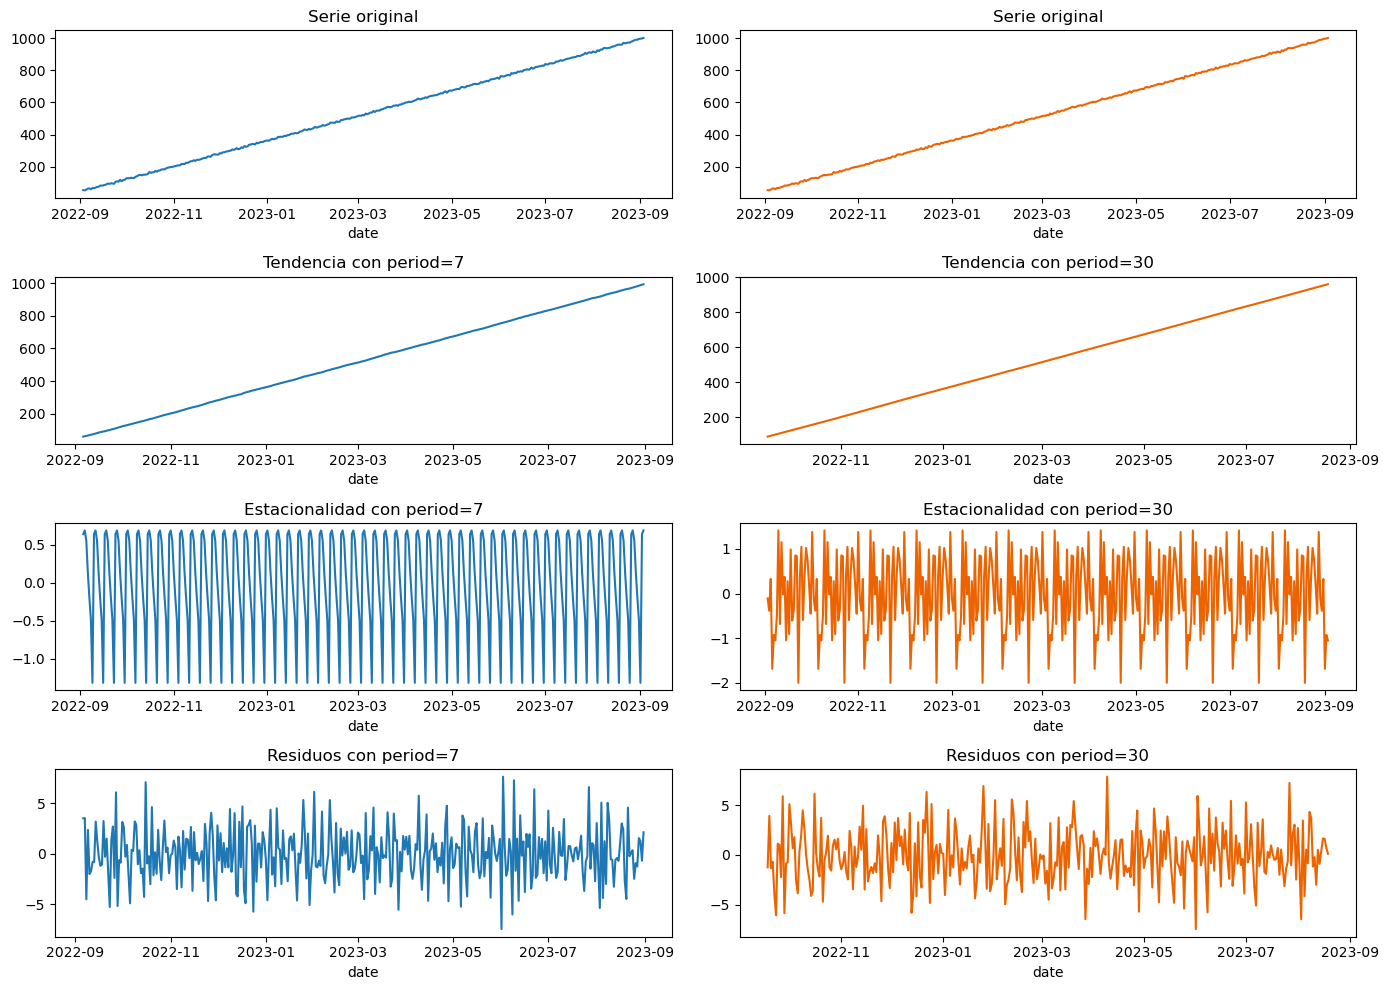

In [154]:
decomposition_7 = seasonal_decompose(df["sales"], period=7)
decomposition_30 = seasonal_decompose(df["sales"], period=30)

fig, axes = plt.subplots(4, 2, figsize=(14, 10))

components_7 = [
    df["sales"],
    decomposition_7.trend,
    decomposition_7.seasonal,
    decomposition_7.resid,
]

components_30 = [
    df["sales"],
    decomposition_30.trend,
    decomposition_30.seasonal,
    decomposition_30.resid,
]

titles_7 = [
    "Serie original",
    "Tendencia con period=7",
    "Estacionalidad con period=7",
    "Residuos con period=7",
]

titles_30 = [
    "Serie original",
    "Tendencia con period=30",
    "Estacionalidad con period=30",
    "Residuos con period=30",
]

for row in range(4):
    sns.lineplot(data=components_7[row], ax=axes[row, 0])
    axes[row, 0].set_title(titles_7[row])
    axes[row, 0].set_ylabel("")

    sns.lineplot(data=components_30[row], ax=axes[row, 1], color="#ed6300")
    axes[row, 1].set_title(titles_30[row])
    axes[row, 1].set_ylabel("")

plt.tight_layout()
plt.show()

### Interpretación de la descomposición

Las dos descomposiciones mantienen una tendencia ascendente clara.

Con `period=7` aparece un patrón repetido muy limpio, lo que puede indicar estacionalidad semanal. Con `period=30` el patrón es menos claro y parece más irregular.

Los residuos no muestran una estructura fuerte. Parecen comportarse como ruido alrededor de cero.

`period=7` parece explicar mejor la parte estacional que `period=30`.

## 8. Estacionariedad

Compruebo si la serie es estacionaria usando la prueba de `Dickey-Fuller`.

Una serie estacionaria mantiene una media y una variabilidad más estables en el tiempo. Esto es importante para `ARIMA`, porque el modelo trabaja mejor cuando la serie no tiene una tendencia fuerte.

La idea principal es revisar el `p-value` para decidir si la serie necesita diferenciación.

In [155]:
def test_stationarity(timeseries):
    print("Resultados de la prueba de Dickey-Fuller:")

    dftest: tuple[Any, ...] = adfuller(timeseries.dropna(), autolag="AIC")

    dfoutput = pd.Series(
        dftest[0:4],
        index=[
            "Test Statistic",
            "p-value",
            "#Lags Used",
            "Number of Observations Used",
        ],
    )

    critical_values = dict(dftest[4])

    for key, value in critical_values.items():
        dfoutput[f"Critical Value ({key})"] = value

    return dfoutput

In [156]:
test_stationarity(df["sales"])

Resultados de la prueba de Dickey-Fuller:


Test Statistic                   0.545414
p-value                          0.986190
#Lags Used                      13.000000
Number of Observations Used    352.000000
Critical Value (1%)             -3.449065
Critical Value (5%)             -2.869786
Critical Value (10%)            -2.571163
dtype: float64

### Interpretación de Dickey-Fuller

El `p-value` es mayor que 0.05, por lo que no puedo considerar la serie como estacionaria.

Esto tiene sentido con lo visto en el gráfico ya que las ventas tienen una tendencia ascendente clara.

Tengo que aplicar diferenciación antes de entrenar el modelo `ARIMA`.

### Posible diferenciación

Si la serie no es estacionaria, se puede aplicar diferenciación para reducir tendencia o patrones acumulados.


In [157]:
sales_diff = df["sales"].diff().dropna()

display(sales_diff)

date
2022-09-04   -1.488946
2022-09-05    4.338482
2022-09-06    6.389205
2022-09-07    1.482734
2022-09-08   -5.931768
                ...   
2023-08-30    0.518681
2023-08-31    5.386972
2023-09-01    0.827090
2023-09-02    1.535798
2023-09-03    3.132571
Freq: D, Name: sales, Length: 365, dtype: float64

In [158]:
test_stationarity(sales_diff)

Resultados de la prueba de Dickey-Fuller:


Test Statistic                -9.430263e+00
p-value                        5.212954e-16
#Lags Used                     1.200000e+01
Number of Observations Used    3.520000e+02
Critical Value (1%)           -3.449065e+00
Critical Value (5%)           -2.869786e+00
Critical Value (10%)          -2.571163e+00
dtype: float64

### Interpretación de la diferenciación

Después de aplicar diferenciación, el `p-value` baja por debajo de 0.05.

La serie diferenciada ya es estacionaria.

Para el modelo `ARIMA`, esto indica que el valor de `d` debería ser 1.

## 9. Variabilidad y residuos

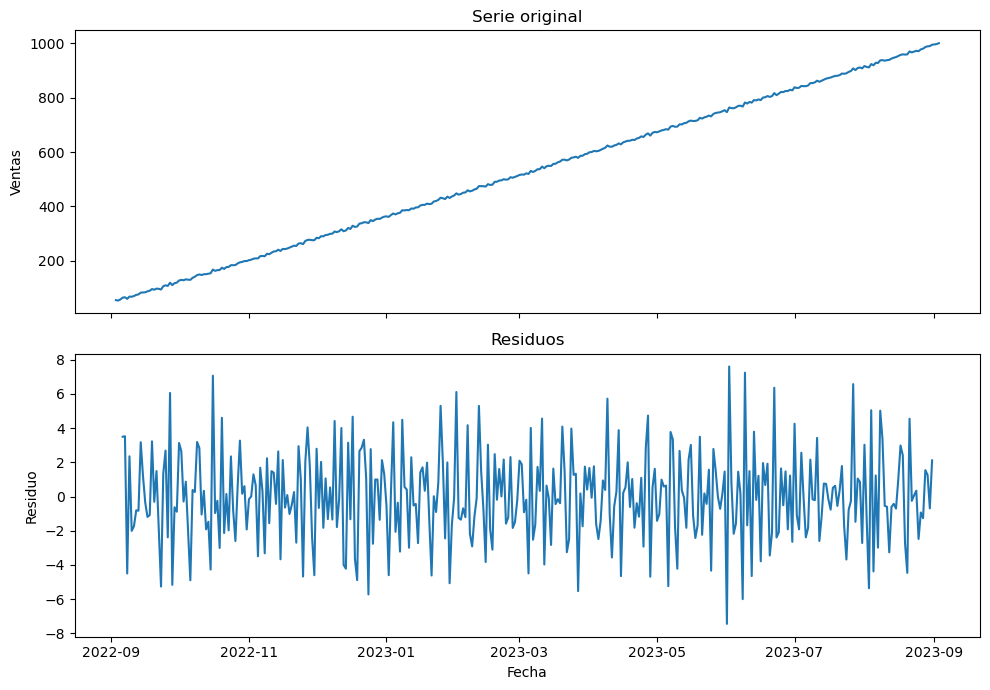

In [159]:
residual = decomposition_7.resid

fig, axis = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axis[0].plot(df.index, df["sales"])
axis[0].set_title("Serie original")
axis[0].set_ylabel("Ventas")

axis[1].plot(residual.index, residual)
axis[1].set_title("Residuos")
axis[1].set_ylabel("Residuo")
axis[1].set_xlabel("Fecha")

plt.tight_layout()
plt.show()

Los residuos se mueven alrededor de 0, aunque tienen bastante variabilidad.

No veo una tendencia clara por lo parece que la descomposición ha separado bien la tendencia principal.

Aparecen picos positivos y negativos fuertes. Algunos parecen repetirse, así que todavía puede quedar algún patrón temporal sin capturar.

Lo voy a revisar con `ACF` y `PACF`.

## 10. Autocorrelación

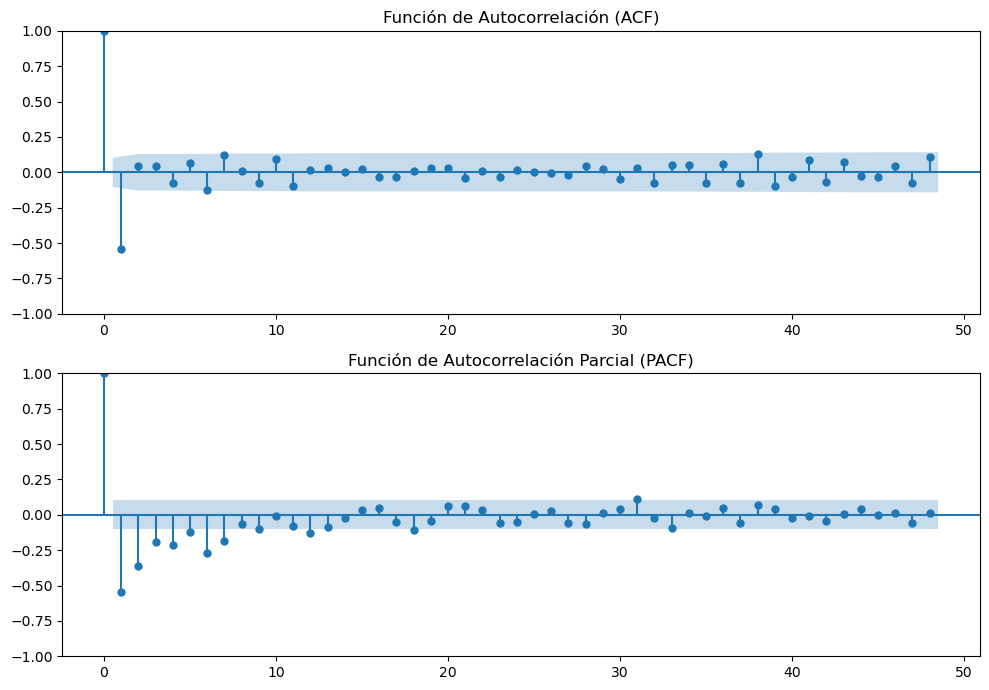

In [160]:
fig, axis = plt.subplots(2, 1, figsize=(10, 7))

plot_acf(sales_diff, lags=48, ax=axis[0])
axis[0].set_title("Función de Autocorrelación (ACF)")

plot_pacf(sales_diff, lags=48, ax=axis[1])
axis[1].set_title("Función de Autocorrelación Parcial (PACF)")

plt.tight_layout()
plt.show()

En la gráfica `ACF` el primer lag aparece con una autocorrelación negativa fuerte. Después la mayoría de valores quedan dentro de la banda de confianza.

La serie diferenciada ya no mantiene una dependencia fuerte con muchos valores anteriores, aunque sí hay una relación clara con el día anterior.

En la gráfica `PACF` también destaca el primer lag. Por eso como primera aproximación voy a usar `p = 1` y `q = 1`.

Como ya apliqué una diferenciación para hacer la serie estacionaria, el valor de `d` sería 1. El primer `modelo manual` razonable sería `ARIMA(1, 1, 1)`.

## 11. Preparación de train y test

Como es una serie temporal, separo los datos respetando el orden cronológico.

No uso una división aleatoria porque eso mezclaría pasado y futuro.

Dejo los últimos 73 días como conjunto de `test`, que representa aproximadamente el 20% del dataset.


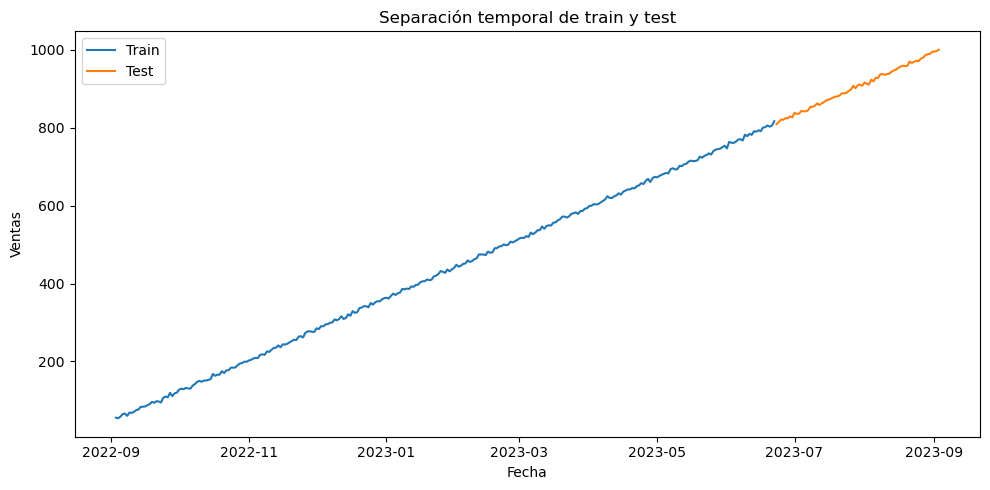

In [161]:
train = df.iloc[:-73]
test = df.iloc[-73:]

fig, axis = plt.subplots(figsize=(10, 5))

sns.lineplot(data=train, x=train.index, y="sales", ax=axis, label="Train")
sns.lineplot(data=test, x=test.index, y="sales", ax=axis, label="Test")

axis.set_title("Separación temporal de train y test")
axis.set_xlabel("Fecha")
axis.set_ylabel("Ventas")

plt.tight_layout()
plt.show()

## 12. Modelo ARIMA manual

Entreno un modelo `ARIMA` usando los parámetros elegidos a partir de la estacionariedad y los gráficos `ACF` y `PACF`.

Uso `p = 1`, `d = 1` y `q = 1`.

In [162]:
p = 1
d = 1
q = 1

model_arima = ARIMA(train["sales"], order=(p, d, q))

result_arima = model_arima.fit()

result_arima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  sales   No. Observations:                  293
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -842.834
Date:               vi., 22 may. 2026   AIC                           1691.668
Time:                        16:59:31   BIC                           1702.698
Sample:                    09-03-2022   HQIC                          1696.086
                         - 06-22-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000      0.002    461.283      0.000       0.996       1.004
ma.L1         -0.9993      1.189     -0.840      0.401      -3.330       1.331
sigma2        18.5272     21.975      0.843      0.399     -24.542      61.596
===================================================================================
Ljung-Box (L1) (Q):                  81.23   Jarque-Bera (JB):                 2.77
Prob(Q):                              0.00   Prob(JB):                         0.25
Heteroskedasticity (H):               1.11   Skew:                             0.24
Prob(H) (two-sided):                  0.61   Kurtosis:                         2.97
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

El `modelo manual` `ARIMA(1, 1, 1)` funciona como primera aproximación.

El parámetro `ar.L1` aparece como significativo, lo que indica que el valor anterior tiene bastante peso en el comportamiento de la serie.

El parámetro `ma.L1` no parece significativo porque su `p-value` es mayor que `0.05`. Esto indica que la parte de media móvil no aporta una señal clara en este primer modelo.

El test de `Ljung-Box` tiene un valor bajo, por lo que todavía puede quedar autocorrelación en los residuos. Por eso, este modelo sirve como primera aproximación, pero podría mejorarse probando otros parámetros o usando `auto_arima`.

## 13. Predicción con ARIMA manual

In [163]:
forecast_arima = result_arima.forecast(steps=len(test))

display(forecast_arima)

2023-06-23     819.495692
2023-06-24     822.079633
2023-06-25     824.663573
2023-06-26     827.247510
2023-06-27     829.831447
                 ...     
2023-08-30     995.200166
2023-08-31     997.784002
2023-09-01    1000.367837
2023-09-02    1002.951670
2023-09-03    1005.535502
Freq: D, Name: predicted_mean, Length: 73, dtype: float64

Genero predicciones con el modelo `ARIMA(1, 1, 1)` para el mismo número de días que tiene el conjunto de `test`.

Así puedo comparar la predicción con los valores reales que el modelo no vio durante el `train`.

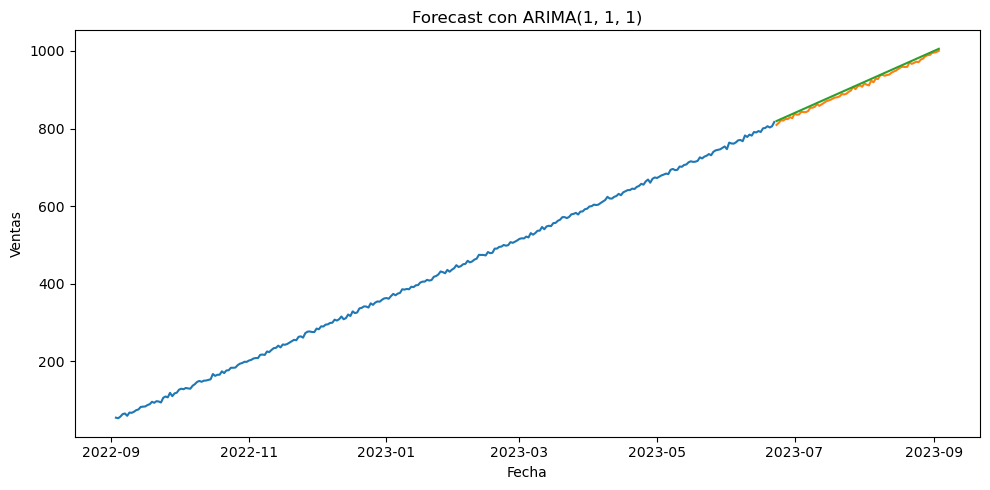

In [164]:
fig, axis = plt.subplots(figsize=(10, 5))

axis.plot(train.index, train["sales"], label="Train")
axis.plot(test.index, test["sales"], label="Test")
axis.plot(forecast_arima.index, forecast_arima, label="Forecast ARIMA")

axis.set_title("Forecast con ARIMA(1, 1, 1)")
axis.set_xlabel("Fecha")
axis.set_ylabel("Ventas")

plt.tight_layout()
plt.show()

La predicción del modelo `ARIMA(1, 1, 1)` sigue bastante bien la tendencia ascendente del conjunto de `test`.

La línea es más suave y casi lineal. No captura bien las pequeñas variaciones diarias.

La predicción queda un poco por encima de los valores reales. El modelo parece sobreestimar ligeramente las ventas.

Este resultado sirve como primera aproximación, pero vamos a intentar mejorarlo con `auto_arima`. A ver qué `p`, `d` y `q` me recomienda.

## 14. Entrenamiento automático con `auto_arima`

`auto_arima` muestra un `warning` de compatibilidad porque `pmdarima` usa internamente un parámetro antiguo de `scikit-learn`.

El `warning` no impide entrenar el modelo con `scikit-learn 1.7.2`, pero en `scikit-learn 1.8.0` sí provoca error.

Por eso fijo las versiones del entorno en `requirements.txt`.

In [165]:
model_auto_arima = auto_arima(train["sales"], seasonal=False, trace=True)

model_auto_arima.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1488.025, Time=0.20 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1683.985, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1588.625, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1484.235, Time=0.07 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1773.606, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1484.182, Time=0.18 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=1486.086, Time=0.21 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=1488.217, Time=0.14 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1484.105, Time=0.13 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=1486.025, Time=0.14 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=0.24 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=1742.890, Time=0.04 sec

Best model:  ARIMA(0,1,2)(0,0,0)[0] intercept
Total fit time: 1.426 seconds


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  293
Model:               SARIMAX(0, 1, 2)   Log Likelihood                -738.052
Date:               vi., 22 may. 2026   AIC                           1484.105
Time:                        16:59:33   BIC                           1498.812
Sample:                    09-03-2022   HQIC                          1489.996
                         - 06-22-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      2.5995      0.013    196.952      0.000       2.574       2.625
ma.L1         -1.0184      0.055    -18.664      0.000      -1.125      -0.911
ma.L2          0.0892      0.055      1.632      0.103      -0.018       0.196
sigma2         9.1169      0.818     11.144      0.000       7.513      10.720
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 1.10
Prob(Q):                              0.98   Prob(JB):                         0.58
Heteroskedasticity (H):               0.99   Skew:                             0.05
Prob(H) (two-sided):                  0.98   Kurtosis:                         2.72
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

`auto_arima` selecciona como mejor modelo un `ARIMA(0, 1, 2)` con `intercept`.

`d = 1` coincide con lo que había visto en la prueba de `Dickey-Fuller`.

El `modelo automático` obtiene un `AIC` de `1484.105`. El `modelo manual` `ARIMA(1, 1, 1)` tenia también un `AIC`.

El `intercept` es significativo (2.5995) y representa un crecimiento medio positivo en la serie diferenciada. Encaja con la tendencia ascendente de las ventas.

El test de `Ljung-Box` tiene un `p-value` alto (0.98). Hay evidencia clara de autocorrelación en los residuos. El `modelo automático` captura mejor la estructura temporal que el primer modelo.

## 15. Predicción del `modelo automático`

Genero predicciones con el `modelo automático` para el mismo número de días que tiene el conjunto de `test`.

Después convierto las predicciones en una serie con el mismo índice temporal que `test` para poder compararlas correctamente con los valores reales.

In [166]:
forecast_auto_arima = model_auto_arima.predict(n_periods=len(test))

forecast_auto_arima = pd.Series(
    forecast_auto_arima,
    index=test.index,
    name="forecast_auto_arima"
)

display(forecast_auto_arima)

date
2023-06-23     812.821451
2023-06-24     815.990356
2023-06-25     818.589903
2023-06-26     821.189450
2023-06-27     823.788998
                 ...     
2023-08-30     990.160023
2023-08-31     992.759570
2023-09-01     995.359117
2023-09-02     997.958664
2023-09-03    1000.558212
Freq: D, Name: forecast_auto_arima, Length: 73, dtype: float64

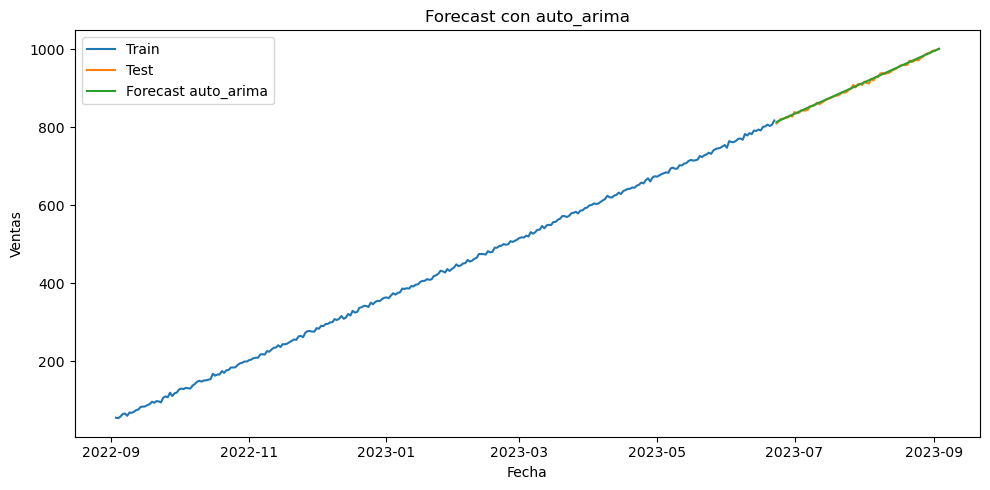

In [167]:
fig, axis = plt.subplots(figsize=(10, 5))

axis.plot(train.index, train["sales"], label="Train")
axis.plot(test.index, test["sales"], label="Test")
axis.plot(forecast_auto_arima.index, forecast_auto_arima, label="Forecast auto_arima")

axis.set_title("Forecast con auto_arima")
axis.set_xlabel("Fecha")
axis.set_ylabel("Ventas")

axis.legend()

plt.tight_layout()
plt.show()

El `forecast` del `modelo automático` se ajusta muy bien al conjunto de `test`.

La línea predicha queda prácticamente superpuesta con los valores reales, por lo que el modelo captura correctamente la tendencia ascendente de las ventas.

A diferencia del `modelo manual`, el `forecast automático` no queda tan desplazado por encima de los valores reales.

Voy a calcular métricas de error para evaluar el rendimiento de forma más objetiva.

## 16. Evaluación del modelo
Evalúo los modelos usando métricas de error sobre el conjunto de `test`.

Uso `MAE`, `RMSE` y `MAPE` para comparar las predicciones con los valores reales.

#### Métricas de los modelos `ARIMA (1, 1, 1)` y `auto_arima (0, 1, 2)`

In [168]:
mae_manual = mean_absolute_error(test["sales"], forecast_arima)
rmse_manual = np.sqrt(mean_squared_error(test["sales"], forecast_arima))
mape_manual = np.mean(np.abs((test["sales"] - forecast_arima) / test["sales"])) * 100

mae_auto = mean_absolute_error(test["sales"], forecast_auto_arima)
rmse_auto = np.sqrt(mean_squared_error(test["sales"], forecast_auto_arima))
mape_auto = np.mean(np.abs((test["sales"] - forecast_auto_arima) / test["sales"])) * 100

metrics = pd.DataFrame(
    {
        "Model": ["ARIMA manual", "auto_arima"],
        "MAE": [mae_manual, mae_auto],
        "RMSE": [rmse_manual, rmse_auto],
        "MAPE": [mape_manual, mape_auto],
    }
)

display(metrics.round(3))

,Model,MAE,RMSE,MAPE
0,ARIMA manual,6.725,7.231,0.749
1,auto_arima,2.371,2.899,0.263


El modelo `auto_arima (0, 1, 2)` obtiene menores valores de `MAE`, `RMSE` y `MAPE`. Predice mejor que el `modelo manual ARIMA(1, 1, 1)`.

`MAE` y `RMSE` están expresados en unidades de ventas. `MAPE` muestra el error medio en porcentaje.

El `MAPE` del `modelo automático` es cercano a `0.26%`. Indica un error muy bajo en el conjunto de `test`.

## 17. Predicción futura

Entreno el `modelo final` usando toda la serie disponible con `ARIMA(0, 1, 2)`.

In [169]:
final_model = ARIMA(df["sales"], order=(0, 1, 2))

final_result = final_model.fit()

display(final_result.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  sales   No. Observations:                  366
Model:                 ARIMA(0, 1, 2)   Log Likelihood               -1078.738
Date:               vi., 22 may. 2026   AIC                           2163.476
Time:                        16:59:33   BIC                           2175.176
Sample:                    09-03-2022   HQIC                          2168.126
                         - 09-03-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3018      0.055     -5.443      0.000      -0.410      -0.193
ma.L2          0.3598      0.053      6.748      0.000       0.255       0.464
sigma2        21.5879      1.659     13.012      0.000      18.336      24.840
===================================================================================
Ljung-Box (L1) (Q):                  19.94   Jarque-Bera (JB):                 2.22
Prob(Q):                              0.00   Prob(JB):                         0.33
Heteroskedasticity (H):               1.04   Skew:                             0.17
Prob(H) (two-sided):                  0.82   Kurtosis:                         2.84
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [170]:
final_auto_arima = auto_arima(
    df["sales"],
    seasonal=False,
    trace=True
)

future_steps = 30

future_forecast = final_auto_arima.predict(n_periods=future_steps)

future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=future_steps,
    freq="D"
)

future_forecast = pd.Series(
    future_forecast,
    index=future_dates,
    name="future_forecast"
)

display(future_forecast)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1843.229, Time=0.43 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2096.542, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1970.972, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1839.586, Time=0.11 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2209.657, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1839.552, Time=0.21 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=1841.532, Time=0.32 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=1843.586, Time=0.14 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1839.607, Time=0.16 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=1922.648, Time=0.06 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=inf, Time=0.23 sec

Best model:  ARIMA(1,1,1)(0,0,0)[0] intercept
Total fit time: 1.742 seconds


2023-09-04    1002.158148
2023-09-05    1004.831668
2023-09-06    1007.423289
2023-09-07    1010.021630
2023-09-08    1012.619419
2023-09-09    1015.217253
2023-09-10    1017.815084
2023-09-11    1020.412915
2023-09-12    1023.010746
2023-09-13    1025.608577
2023-09-14    1028.206408
2023-09-15    1030.804239
2023-09-16    1033.402070
2023-09-17    1035.999901
2023-09-18    1038.597733
2023-09-19    1041.195564
2023-09-20    1043.793395
2023-09-21    1046.391226
2023-09-22    1048.989057
2023-09-23    1051.586888
2023-09-24    1054.184719
2023-09-25    1056.782550
2023-09-26    1059.380381
2023-09-27    1061.978212
2023-09-28    1064.576043
2023-09-29    1067.173874
2023-09-30    1069.771705
2023-10-01    1072.369536
2023-10-02    1074.967367
2023-10-03    1077.565198
Freq: D, Name: future_forecast, dtype: float64

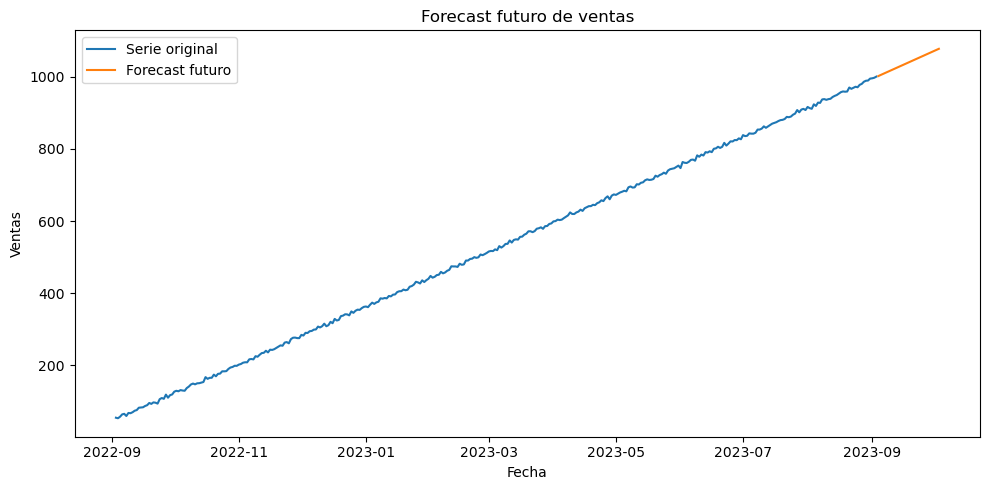

In [171]:
fig, axis = plt.subplots(figsize=(10, 5))

axis.plot(df.index, df["sales"], label="Serie original")
axis.plot(future_forecast.index, future_forecast, label="Forecast futuro")

axis.set_title("Forecast futuro de ventas")
axis.set_xlabel("Fecha")
axis.set_ylabel("Ventas")

axis.legend()

plt.tight_layout()
plt.show()

**IMPORTANTE**:

Al reentrenar `auto_arima` con toda la serie, el modelo seleccionado cambia a `ARIMA(1, 1, 1) con intercept`.

El `forecast futuro` mantiene la tendencia ascendente que ya se observaba antes.

La predicción debe interpretarse como una estimación de la dirección esperada de las ventas.

El modelo se basa en la estructura histórica de la serie. **`La incertidumbre aumenta`** cuanto más lejos se proyecta hacia el futuro.

## 18. Guardado del modelo

Guardo el `modelo final_auto_arima` porque es el modelo final entrenado con toda la serie disponible.

In [172]:
model_path = "../models/final_auto_arima_sales_model.pkl"

joblib.dump(final_auto_arima, model_path)

print(f"Modelo guardado en: {model_path}")

Modelo guardado en: ../models/final_auto_arima_sales_model.pkl


## 19. Conclusiones

Las `ventas` muestran una `tendencia ascendente muy clara` durante todo el periodo analizado.

La serie original `no` era `estacionaria`. Esto se confirmó con la prueba de `Dickey-Fuller`, donde el `p-value` fue mayor que `0.05`.

Después de aplicar una primera `diferenciación`, la serie pasó a ser `estacionaria`. Por eso, el valor de `d` para el `modelo ARIMA` quedó en `1`.

El primer `modelo manual` fue `ARIMA(1, 1, 1)`. Sirvió como primera aproximación, pero la `predicción` quedaba algo por encima de los valores reales y era bastante lineal.

Después usé `auto_arima`, que seleccionó un `modelo ARIMA(0, 1, 2)` para comparar sobre el `conjunto de test`. Este modelo obtuvo `mejores métricas` que el `modelo manual`.

El `MAPE` del `modelo automático` fue cercano a `0.26%`, por lo que el `error porcentual medio` fue muy bajo en el `conjunto de test`.

Al entrenar el `modelo final` con toda la serie, `auto_arima` seleccionó un `ARIMA(1, 1, 1) con intercept`. Con este modelo generé un `forecast` de 30 días.

**El `forecast` mantiene la `tendencia ascendente de las ventas`. Esto puede `ayudar a estimar la demanda futura` y `tomar una mejor decisión sobre el espacio necesario para el nuevo almacén`.**
